# SmartHome Valuator — EDA y Entrenamiento XGBoost
Orden: carga → EDA → separación → preprocesamiento → entrenamiento → guardado de artefactos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid')
MODELS_DIR = '../services/ml/models'
os.makedirs(MODELS_DIR, exist_ok=True)

## 1. Carga del dataset

In [3]:
# Fila 0 = categorías agrupadas (ignorar), fila 1 = nombres reales de columnas
df = pd.read_csv('../data/raw/SmartHome_Valuator_Dataset_CLEAN.csv', skiprows=1)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (1200, 25)


,ID Registro,Fuente,Tipo Operación,Tipo Inmueble,Área (m²),Habitaciones,Baños,Parqueadero,Depósito,Antigüedad (años),...,Hurto Res./100k hab,Índice Seguridad (0-10),Acueducto+Alcantarillado (COP/mes),Consumo Energía (kWh/mes),Energía Eléctrica (COP/mes),Admin. Mensual (COP),TCO Mensual Est. (COP),Precio Venta (COP),Precio Arriendo (COP/mes),PRECIO MERCADO (COP) ★
0,SHV-0001,Properati,Venta,Apartamento,194,4,4,Sí,Sí,30,...,180,5.58,173000,524,542000,2399000,3114000,2302800000,11450000,2302800000
1,SHV-0002,Habi,Venta,Apartamento,73,3,2,Sí,Sí,48,...,320,1.00,87000,190,131000,342000,560000,479400000,2020000,479400000
2,SHV-0003,Habi,Venta,Apartamento,79,3,2,No,No,42,...,290,1.98,46000,162,89000,266000,401000,272900000,1220000,272900000


## 2. EDA básico

In [4]:
print('Tipos de datos:')
print(df.dtypes)
print('\nNulos por columna:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Tipos de datos:
ID Registro                               str
Fuente                                    str
Tipo Operación                            str
Tipo Inmueble                             str
Área (m²)                               int64
Habitaciones                            int64
Baños                                   int64
Parqueadero                               str
Depósito                                  str
Antigüedad (años)                       int64
Localidad                                 str
UPZ                                       str
Estrato                                 int64
Latitud                               float64
Longitud                              float64
Hurto Res./100k hab                     int64
Índice Seguridad (0-10)               float64
Acueducto+Alcantarillado (COP/mes)      int64
Consumo Energía (kWh/mes)               int64
Energía Eléctrica (COP/mes)             int64
Admin. Mensual (COP)                    int64
TCO Mensual Est. (

In [5]:
print('Distribución por Tipo Operación:')
print(df['Tipo Operación'].value_counts())

Distribución por Tipo Operación:
Tipo Operación
Venta       728
Arriendo    472
Name: count, dtype: int64


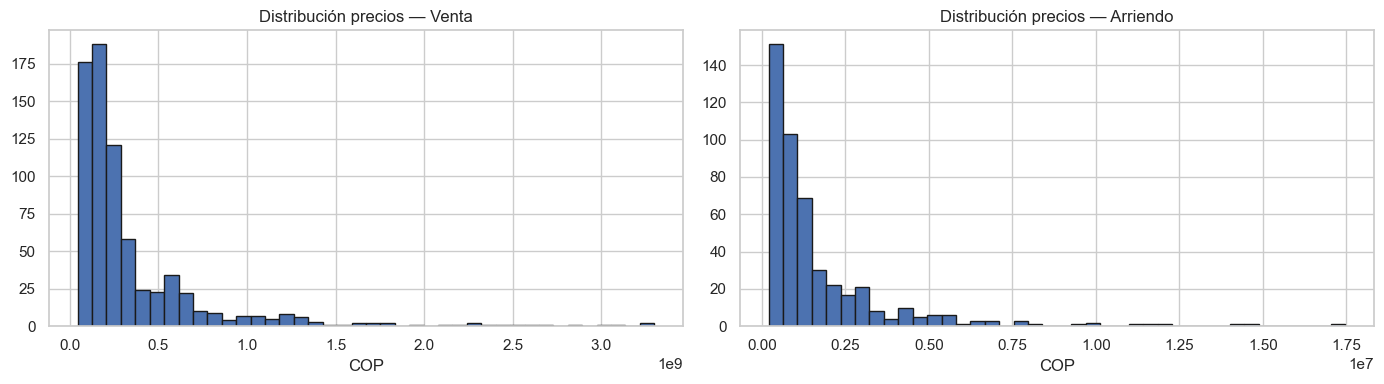

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, tipo in zip(axes, ['Venta', 'Arriendo']):
    subset = df[df['Tipo Operación'] == tipo]['PRECIO MERCADO (COP) ★'].dropna()
    ax.hist(subset, bins=40, edgecolor='k')
    ax.set_title(f'Distribución precios — {tipo}')
    ax.set_xlabel('COP')
plt.tight_layout()
plt.show()

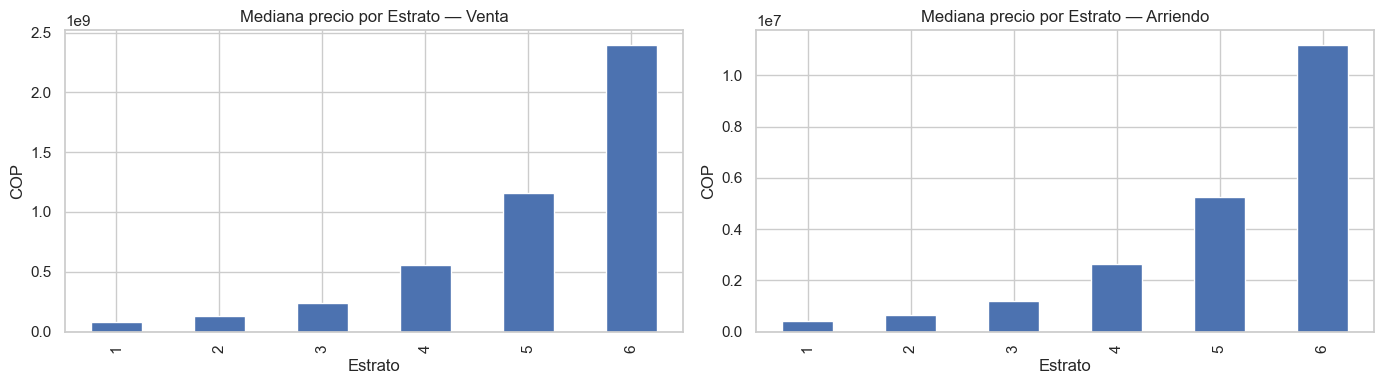

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, tipo in zip(axes, ['Venta', 'Arriendo']):
    subset = df[df['Tipo Operación'] == tipo]
    mediana = subset.groupby('Estrato')['PRECIO MERCADO (COP) ★'].median()
    mediana.plot(kind='bar', ax=ax, title=f'Mediana precio por Estrato — {tipo}')
    ax.set_xlabel('Estrato')
    ax.set_ylabel('COP')
plt.tight_layout()
plt.show()

## 3. Separación Venta / Arriendo

In [8]:
mask_venta = df['Tipo Operación'] == 'Venta'
mask_arriendo = df['Tipo Operación'] == 'Arriendo'
df_venta = df[mask_venta].copy()
df_arriendo = df[mask_arriendo].copy()
print(f'Venta: {len(df_venta)} | Arriendo: {len(df_arriendo)}')

Venta: 728 | Arriendo: 472


## 4. Preprocesamiento

In [9]:
FEATURES_NUM = [
    'Área (m²)', 'Habitaciones', 'Baños', 'Antigüedad (años)',
    'Estrato', 'Latitud', 'Longitud', 'Hurto Res./100k hab',
    'Índice Seguridad (0-10)', 'Acueducto+Alcantarillado (COP/mes)',
    'Consumo Energía (kWh/mes)', 'Energía Eléctrica (COP/mes)',
    'Admin. Mensual (COP)',
]
FEATURES_CAT = ['Tipo Inmueble', 'Localidad', 'UPZ']
TARGET = 'PRECIO MERCADO (COP) ★'

def preprocess(df_in: pd.DataFrame):
    df_p = df_in.copy()

    # Booleanos
    df_p['Parqueadero'] = df_p['Parqueadero'].map({'Sí': 1, 'No': 0}).fillna(0).astype(int)
    df_p['Depósito'] = df_p['Depósito'].map({'Sí': 1, 'No': 0}).fillna(0).astype(int)

    # Numéricos
    for col in FEATURES_NUM:
        df_p[col] = pd.to_numeric(df_p[col], errors='coerce')
        df_p[col] = df_p[col].fillna(df_p[col].median())

    # Label encoding de categóricas
    encoders = {}
    for col in FEATURES_CAT:
        le = LabelEncoder()
        df_p[col] = le.fit_transform(df_p[col].astype(str))
        encoders[col] = le

    # Eliminar filas sin target
    df_p = df_p.dropna(subset=[TARGET])
    df_p = df_p[df_p[TARGET] > 0]

    feature_cols = FEATURES_NUM + FEATURES_CAT + ['Parqueadero', 'Depósito']
    X = df_p[feature_cols]
    y = df_p[TARGET]
    return X, y, encoders

X_venta, y_venta, enc_venta = preprocess(df_venta)
X_arriendo, y_arriendo, enc_arriendo = preprocess(df_arriendo)
print(f'X_venta: {X_venta.shape} | X_arriendo: {X_arriendo.shape}')

X_venta: (728, 18) | X_arriendo: (472, 18)


## 5. Split 70% train / 15% val / 15% test

In [10]:
def split_data(X, y):
    X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=42)
    X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=42)
    return X_tr, X_val, X_te, y_tr, y_val, y_te

Xtr_v, Xval_v, Xte_v, ytr_v, yval_v, yte_v = split_data(X_venta, y_venta)
Xtr_a, Xval_a, Xte_a, ytr_a, yval_a, yte_a = split_data(X_arriendo, y_arriendo)
print(f'Venta  → train {len(Xtr_v)} | val {len(Xval_v)} | test {len(Xte_v)}')
print(f'Arriendo → train {len(Xtr_a)} | val {len(Xval_a)} | test {len(Xte_a)}')

Venta  → train 509 | val 109 | test 110
Arriendo → train 330 | val 71 | test 71


## 6. Entrenamiento — Modelo Venta

In [15]:
def train_and_evaluate(Xtr, ytr, Xval, yval, Xte, yte, label: str):
    print('\n[' + label + '] y_train.describe():')
    print(ytr.describe())

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='rmse',
        early_stopping_rounds=20,
    )

    model.fit(
        Xtr, ytr,
        eval_set=[(Xval, yval)],
        verbose=False,
    )

    y_pred = model.predict(Xte)
    r2 = r2_score(yte, y_pred)
    rmse = np.sqrt(mean_squared_error(yte, y_pred))
    mae = mean_absolute_error(yte, y_pred)

    print('\n=== ' + label + ' ===')
    print('  R²   : ' + str(round(r2, 4)))
    print('  RMSE : {:,.0f} COP'.format(rmse))
    print('  MAE  : {:,.0f} COP'.format(mae))

    return model


model_venta = train_and_evaluate(
    Xtr_v, ytr_v,
    Xval_v, yval_v,
    Xte_v, yte_v,
    'XGBoost Venta'
)



[XGBoost Venta] y_train.describe():
count    5.090000e+02
mean     3.643450e+08
std      4.634208e+08
min      4.750000e+07
25%      1.285000e+08
50%      2.080000e+08
75%      3.866000e+08
max      3.298700e+09
Name: PRECIO MERCADO (COP) ★, dtype: float64

=== XGBoost Venta ===
  R²   : 0.9375
  RMSE : 91,414,842 COP
  MAE  : 37,710,680 COP


## 7. Entrenamiento — Modelo Arriendo

In [16]:
model_arriendo = train_and_evaluate(Xtr_a, ytr_a, Xval_a, yval_a, Xte_a, yte_a, 'XGBoost Arriendo')


[XGBoost Arriendo] y_train.describe():
count    3.300000e+02
mean     1.627697e+06
std      1.854984e+06
min      2.000000e+05
25%      5.500000e+05
50%      9.500000e+05
75%      1.885000e+06
max      1.433000e+07
Name: PRECIO MERCADO (COP) ★, dtype: float64

=== XGBoost Arriendo ===
  R²   : 0.848
  RMSE : 1,131,019 COP
  MAE  : 359,988 COP


## 8. Importancia de features

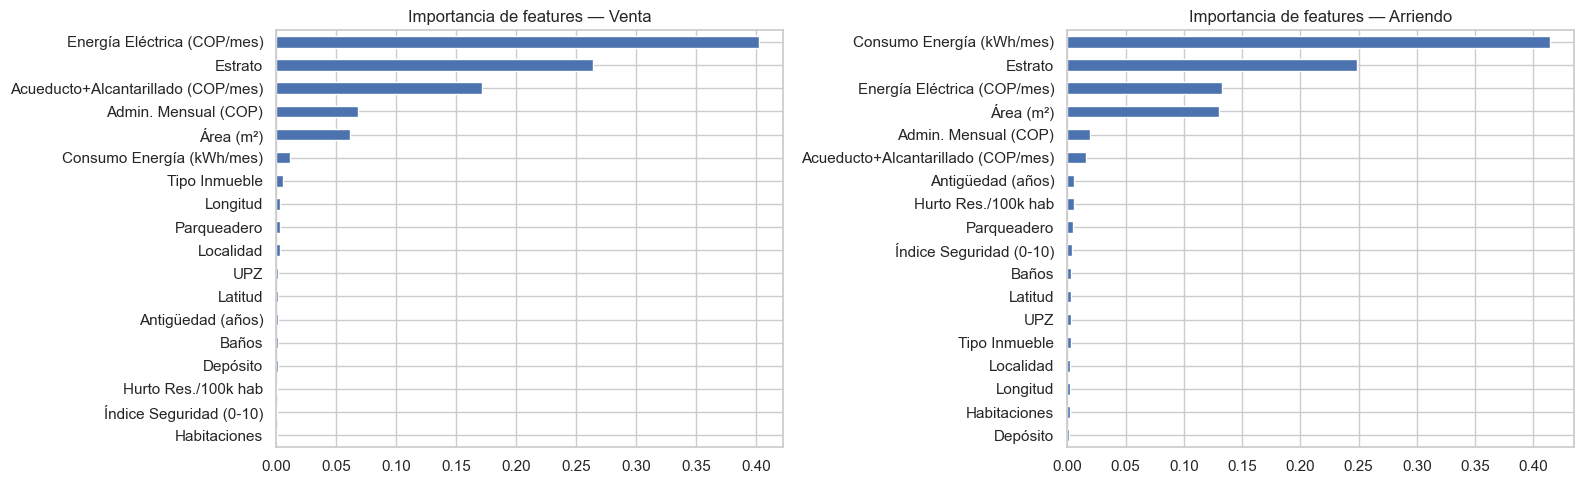

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, model, label in zip(axes, [model_venta, model_arriendo], ['Venta', 'Arriendo']):
    feat_imp = pd.Series(model.feature_importances_, index=X_venta.columns).sort_values(ascending=True)
    feat_imp.plot(kind='barh', ax=ax, title=f'Importancia de features — {label}')
plt.tight_layout()
plt.show()

## 9. Guardar artefactos en services/ml/models/

In [18]:
joblib.dump(model_venta,    os.path.join(MODELS_DIR, 'xgboost_venta.pkl'))
joblib.dump(model_arriendo, os.path.join(MODELS_DIR, 'xgboost_arriendo.pkl'))

# Renombrar claves para que coincidan con los nombres internos del ML Service
rename = {
    'Tipo Inmueble': 'tipo_inmueble',
    'Localidad': 'localidad',
    'UPZ': 'upz',
}
enc_venta_renamed    = {rename.get(k, k): v for k, v in enc_venta.items()}
enc_arriendo_renamed = {rename.get(k, k): v for k, v in enc_arriendo.items()}

joblib.dump(enc_venta_renamed,    os.path.join(MODELS_DIR, 'encoders_venta.pkl'))
joblib.dump(enc_arriendo_renamed, os.path.join(MODELS_DIR, 'encoders_arriendo.pkl'))

print('Artefactos guardados:')
for f in os.listdir(MODELS_DIR):
    print(f'  {MODELS_DIR}/{f}')

Artefactos guardados:
  ../services/ml/models/.gitkeep
  ../services/ml/models/encoders_arriendo.pkl
  ../services/ml/models/encoders_venta.pkl
  ../services/ml/models/xgboost_arriendo.pkl
  ../services/ml/models/xgboost_venta.pkl
